In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from diomics.models.fc_imv import FC_Marginal, JointVAE

import numpy as np
import pandas as pd
import copy

from sklearn.metrics import roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt

## Example of a forward pass on fake data

In [2]:
# two arbitrary views, one with 1000 features, and another with 500 features
marg_model1 = FC_Marginal(input_size=1000, hidden_sizes=[128, 128], z_dim=10, prediction_dim=10)
marg_model2 = FC_Marginal(input_size=500, hidden_sizes=[64, 64], z_dim=10, prediction_dim=10)

# joint model
joint_model = JointVAE(marginal_models=[marg_model1, marg_model2], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-3)

In [3]:
# fake inputs/targets
example_input1 = torch.randn(100, 1000)
example_input2 = torch.randn(100, 500)
example_target = torch.randint(0, 10, (100,))

In [4]:
# get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
yhat, poe_dist, yhats, dists = joint_model([example_input1, example_input2])

In [5]:
# pass the predictions and distributions to the loss function and update parameters
loss = joint_model.loss(example_target, yhat, poe_dist, yhats, dists)
loss.backward()

## Example with real data

In [4]:
proData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_proteins_luke.csv')
lipData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/ICL104_lipids_aligned_for_stats.xlsx")
metabData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/OMICS_ICL104_Metabolomics_YMK.xlsx")
metabData = metabData.drop(columns=['KEGG', 'CAS', 'PubChem'])

fmeta = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_fmeta.csv')

In [9]:
# significant biomolecules
pro_anova = pd.read_csv("./data/anova_results/pep/anova_results.csv")
lip_pos_anova = pd.read_csv("./data/anova_results/lip_pos/anova_results.csv")
# lip_neg_anova = pd.read_csv("./data/anova_results/lip_neg/anova_results.csv")
metab_anova = pd.read_csv("./data/anova_results/metab/anova_results.csv")

In [260]:
# some samples missing from some datasets.
lipData.shape, metabData.shape, proData.shape|

((250, 61), (138, 61), (2853, 61))

In [5]:
# make the id column in the data the index
lipData = lipData.set_index('Name')
metabData = metabData.set_index('Metabolite')
proData = proData.set_index('Protein')

# replace zeros with NA
lipData[lipData == 0] = np.nan
metabData[metabData == 0] = np.nan

# log2 transform the data and column-wise median center
lipData = np.log2(lipData)
metabData = np.log2(metabData)
# proData = np.log2(proData) # already log 2

lipData = lipData - lipData.median(axis=0)
metabData = metabData - metabData.median(axis=0)
proData = proData - proData.median(axis=0)

# [0, 1] normalize all the data
lipData = (lipData - np.min(lipData)) / (np.max(lipData) - np.min(lipData))
metabData = (metabData - np.min(metabData)) / (np.max(metabData) - np.min(metabData))
proData = (proData - np.min(proData)) / (np.max(proData) - np.min(proData))

In [6]:
# columns are nicely aligned
y = pd.Series(['Cal' if 'Cal04' in el else 'Mock' for el in lipData.columns])

In [7]:
# drop indices with all null values
lip_inds = (lipData.isnull() == False).sum(axis = 1) > 0
metab_inds = (metabData.isnull() == False).sum(axis = 1) > 0
pro_inds = (proData.isnull() == False).sum(axis = 1) > 0

lipData = lipData[lip_inds]
metabData = metabData[metab_inds]
proData = proData[pro_inds]

# impute the datasets with the row means
lipData = lipData.apply(lambda row: row.fillna(row.mean()), axis=1)
metabData = metabData.apply(lambda row: row.fillna(row.mean()), axis=1)
proData = proData.apply(lambda row: row.fillna(row.mean()), axis=1)

In [10]:
lip_pos_anova = lip_pos_anova[lip_pos_anova.Lipid.isin(lipData.index)]
metab_anova = metab_anova[metab_anova.Metabolite.isin(metabData.index)]
pro_anova = pro_anova[pro_anova.Protein.isin(proData.index)]

lip_pos_anova.shape, metab_anova.shape, pro_anova.shape

((250, 8), (133, 8), (2853, 8))

In [11]:
# optionally subset the data to only include significant biomolecules
sig_lipids = lip_pos_anova[lip_pos_anova["P_value_A_Cal04_vs_Mock"] < 0.05].Lipid
sig_metabs = metab_anova[metab_anova["P_value_A_Cal04_vs_Mock"] < 0.05].Metabolite
sig_proteins = pro_anova[pro_anova["P_value_A_Cal04_vs_Mock"] < 0.05].Protein

lipData = lipData.loc[sig_lipids]
metabData = metabData.loc[sig_metabs]
proData = proData.loc[sig_proteins]

lipData.shape, metabData.shape, proData.shape

((118, 60), (25, 60), (416, 60))

In [12]:
# get the elements in lipData.columns that are in fmeta['SampleID_lipidpos']
# lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
# metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
# proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]

np.random.seed(1565)
cal_inds = np.random.choice(np.where(y == 'Cal')[0], int(np.sum(y == 'Cal') * 0.2))
mock_inds = np.random.choice(np.where(y == 'Mock')[0], int(np.sum(y == 'Mock') * 0.2))
test_inds = np.concatenate([cal_inds, mock_inds])

train_inds = np.isin(np.arange(y.shape[0]), test_inds) == False

train_lip = lipData.iloc[:,train_inds]
train_pro = proData.iloc[:,train_inds]
train_metab = metabData.iloc[:,train_inds]

test_lip = lipData.iloc[:, test_inds]
test_pro = proData.iloc[:, test_inds]
test_metab = metabData.iloc[:, test_inds]

ytrain = y.iloc[train_inds]
ytest = y.iloc[test_inds]

### Construct the Model

In [13]:
# three view-specific encoders with the appropriate input size:
lip_marg = FC_Marginal(input_size=train_lip.shape[0], hidden_sizes=[128, 128], z_dim=10, prediction_dim=y.nunique())
metab_marg = FC_Marginal(input_size=train_metab.shape[0], hidden_sizes=[64, 64], z_dim=10, prediction_dim=y.nunique())
pro_marg = FC_Marginal(input_size=train_pro.shape[0], hidden_sizes=[256, 128], z_dim=10, prediction_dim=y.nunique())

# joint model
joint_model = JointVAE(marginal_models=[lip_marg, metab_marg, pro_marg], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-3)

In [14]:
# turn data into tensors
lip_tensor = torch.tensor(train_lip.T.values, dtype=torch.float32)
pro_tensor = torch.tensor(train_pro.T.values, dtype=torch.float32)
metab_tensor = torch.tensor(train_metab.T.values, dtype=torch.float32)

y_gt = ytrain.astype('category').cat.codes
y_gt = torch.tensor(y_gt.values, dtype=torch.int64)

for i in range(2000):

    views = [lip_tensor, metab_tensor, pro_tensor]
    
    # randomly drop an index with low probability
    if np.random.rand() < 0.1:
        idx = np.random.randint(0, len(views))
        views = [v if i != idx else None for i, v in enumerate(views)]

    # get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
    yhat, poe_dist, yhats, dists = joint_model(views)

    # pass the predictions and distributions to the loss function and update parameters
    loss = joint_model.loss(y_gt, yhat, poe_dist, yhats, dists)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
    optimizer.step()

    print(f'Epoch {i+1} loss: {loss.item():.3f}')

Epoch 1 loss: 47.827
Epoch 2 loss: 46.440
Epoch 3 loss: 53.320
Epoch 4 loss: 49.594
Epoch 5 loss: 51.679
Epoch 6 loss: 52.942
Epoch 7 loss: 50.944
Epoch 8 loss: 54.662
Epoch 9 loss: 55.193
Epoch 10 loss: 54.390
Epoch 11 loss: 49.427
Epoch 12 loss: 47.891
Epoch 13 loss: 54.029
Epoch 14 loss: 51.855
Epoch 15 loss: 52.437
Epoch 16 loss: 51.460
Epoch 17 loss: 35.705
Epoch 18 loss: 52.759
Epoch 19 loss: 49.499
Epoch 20 loss: 51.029
Epoch 21 loss: 51.358
Epoch 22 loss: 50.306
Epoch 23 loss: 36.598
Epoch 24 loss: 49.435
Epoch 25 loss: 50.209
Epoch 26 loss: 48.370
Epoch 27 loss: 32.815
Epoch 28 loss: 49.686
Epoch 29 loss: 45.913
Epoch 30 loss: 49.588
Epoch 31 loss: 53.864
Epoch 32 loss: 48.810
Epoch 33 loss: 51.799
Epoch 34 loss: 49.967
Epoch 35 loss: 46.813
Epoch 36 loss: 46.936
Epoch 37 loss: 49.705
Epoch 38 loss: 49.184
Epoch 39 loss: 48.433
Epoch 40 loss: 48.364
Epoch 41 loss: 45.587
Epoch 42 loss: 47.011
Epoch 43 loss: 50.463
Epoch 44 loss: 49.542
Epoch 45 loss: 50.795
Epoch 46 loss: 46.2

In [15]:
# example prediction
joint_model.eval()

ytest_gt = ytest.astype('category').cat.codes

liptest_tensor = torch.tensor(test_lip.T.values, dtype=torch.float32)
protest_tensor = torch.tensor(test_pro.T.values, dtype=torch.float32)
metabtest_tensor = torch.tensor(test_metab.T.values, dtype=torch.float32)

with torch.inference_mode():
    yhat, poe_dist, yhats, dists = joint_model([liptest_tensor, metabtest_tensor, protest_tensor])

ypred = yhat.argmax(dim=1).numpy()

(ypred == ytest_gt.to_numpy()).mean()

1.0

In [16]:
confusion_matrix(ytest_gt, ypred)

array([[6, 0],
       [0, 6]])

In [17]:
# order is lip metab pro
(
    (yhats[0].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[1].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[2].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean()
)

(0.9166666666666666, 1.0, 1.0)

In [50]:
pred_lip = yhats[0].argmax(dim=1).numpy()
pred_pro = yhats[1].argmax(dim=1).numpy()
pred_metab = yhats[2].argmax(dim=1).numpy()

(
    confusion_matrix(ytest_gt.to_numpy(), pred_lip),
    confusion_matrix(ytest_gt.to_numpy(), pred_pro),
    confusion_matrix(ytest_gt.to_numpy(), pred_metab)
)

(array([[6, 0],
        [4, 2]]),
 array([[6, 0],
        [3, 3]]),
 array([[4, 2],
        [2, 4]]))

# Variable Importance

## Gradient analysis

As a first pass for variable importance, I simply take the gradient of input input w.r.t. the predicted output probability of the positive class.  Essentially I am trying to determine which input biomolecules are important for the ability of the model to predict the positive class.

In [186]:
# get a single positive example (-1, the last example is positive)
liptest_pos = torch.clone(liptest_tensor[-1].unsqueeze(0))
protest_pos = torch.clone(protest_tensor[-1].unsqueeze(0))
metabtest_pos = torch.clone(metabtest_tensor[-1].unsqueeze(0))

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, poe_dist, yhats, dists = joint_model([liptest_pos, metabtest_pos, protest_pos])


In [187]:
yhat[0,1].backward()

In [53]:
# get the gradients and multiply by the input
# (
# liptest_pos.grad.abs().argsort()[:,:10],
# protest_pos.grad.abs().argsort()[:,:10],
# metabtest_pos.grad.abs().argsort()[:,:10]
# )

liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.argsort()[:,:10],
protest_scores.argsort()[:,:10],
metabtest_scores.argsort()[:,:10]
)

(tensor([[243, 236,   3,  35, 177, 205,  23, 230, 226, 246]]),
 tensor([[ 430,  311,  649, 1398, 1441,   11,  889, 1101, 1397, 1391]]),
 tensor([[ 62,  75, 108, 124,  10,  17,  84, 107, 106,  41]]))

In [19]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, poe_dist, yhats, dists = joint_model([liptest_pos, metabtest_pos, protest_pos])

In [20]:
yhat[:,1].mean().backward()

In [21]:
# (
# liptest_pos.grad.abs().sum(axis=0).argsort()[:10],
# protest_pos.grad.abs().sum(axis=0).argsort()[:10],
# metabtest_pos.grad.abs().sum(axis=0).argsort()[:10]
# )

liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.sum(axis = 0).argsort()[:10],
protest_scores.sum(axis = 0).argsort()[:10],
metabtest_scores.sum(axis = 0).argsort()[:10]
)

(tensor([  3, 240, 123, 204,   4,   8,   2,   1, 243, 140]),
 tensor([1189, 2190, 1188, 2962,   61,   46, 2601, 1349, 2216,   91]),
 tensor([  4, 109, 119, 130,  45,  62, 104,  16, 112,  52]))

# Integrated Gradients

Integrated gradients overcome the problem of non-sensitivity of gradients methods, see https://arxiv.org/pdf/1703.01365.pdf for an explanation.  

As described in the paper, we start at some 'non-informative' baseline, and move linearly towards our actual input, taking the gradient at each step and accumulating.  At the end we divide by the number of steps to get the average gradient, which approximates and integral.  This is the integrated gradient.

In [188]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])


In [189]:
def integrated_grads(views, baselines, model, n_steps = 100, class_idx = 1):
    grads = [torch.zeros_like(v) for v in baselines]
    for i in range(1, n_steps + 1):
        tmp = [torch.clone(b) for b in baselines]
        tmp = [b + i * (vtest - b) for b, vtest in zip(tmp, views)]
        tmp = [b.requires_grad_() for b in tmp]
        yhat, poe_dist, yhats, dists = model(tmp)
        yhat[:,class_idx].mean().backward()
        grads = [g + b.grad for g, b in zip(grads, tmp)]

    return [g * (v - b) / n_steps for g, b, v in zip(grads, baselines, views)]

In [190]:
# move along the baseline (noise) to input, take the gradient at each step, and accumulate.  Divide at the end to form an average.
# lip_baseline = torch.randn_like(liptest_pos, requires_grad = True)*liptest_pos.std() + liptest_pos.mean()
# pro_baseline = torch.randn_like(protest_pos, requires_grad = True)*protest_pos.std() + protest_pos.mean()
# metab_baseline = torch.randn_like(metabtest_pos, requires_grad = True)*metabtest_pos.std() + metabtest_pos.mean()

# grad_lip = torch.zeros_like(lip_baseline)
# grad_pro = torch.zeros_like(pro_baseline)
# grad_metab = torch.zeros_like(metab_baseline)

# n_steps = 100

# for i in range(1, n_steps + 1):
#     tmp_lip = torch.clone(lip_baseline)
#     tmp_pro = torch.clone(pro_baseline)
#     tmp_metab = torch.clone(metab_baseline)

#     tmp_lip = tmp_lip + i * (liptest_pos - tmp_lip)/n_steps
#     tmp_pro = tmp_pro + i * (protest_pos - tmp_pro)/n_steps
#     tmp_metab = tmp_metab + i * (metabtest_pos - tmp_metab)/n_steps

#     tmp_lip.requires_grad = True
#     tmp_pro.requires_grad = True
#     tmp_metab.requires_grad = True

#     yhat, poe_dist, yhats, dists = joint_model([tmp_lip, tmp_metab, tmp_pro])

#     yhat[:,1].mean().backward()

#     grad_lip += tmp_lip.grad
#     grad_pro += tmp_pro.grad
#     grad_metab += tmp_metab.grad


In [191]:
# baseline is normal noise with mean and std from the data
# vary these to see if we get different results...
# scree plot
# lip_baseline = torch.randn_like(liptest_pos)*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
# pro_baseline = torch.randn_like(protest_pos)*protest_pos.std().numpy() + protest_pos.mean().numpy()
# metab_baseline = torch.randn_like(metabtest_pos)*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()


In [192]:
joint_model.eval()

lip_int_scores, metab_int_scores, pro_int_scores = integrated_grads(
    [liptest_pos, metabtest_pos, protest_pos], 
    [lip_baseline, metab_baseline, pro_baseline], 
    joint_model, n_steps = 100, class_idx = 1
)

In [193]:
top_lip = lip_int_scores.sum(axis = 0).argsort()[:10]
top_pro = pro_int_scores.sum(axis = 0).argsort()[:10]
top_metab = metab_int_scores.sum(axis = 0).argsort()[:10]

(
top_lip,
top_pro,
top_metab
)

(tensor([  3, 240,  95,   4, 123, 204, 236,   0,   5,   6]),
 tensor([ 482, 1609, 1616, 1615, 1167, 1601, 1253, 1603, 1671,  348]),
 tensor([ 39,   2,  34,  62,   9,  83, 114,  46,  73,  54]))

In [194]:
sorted_lip_scores = sorted(lip_int_scores.sum(axis = 0).numpy(), reverse = True)
sorted_pro_scores = sorted(pro_int_scores.sum(axis = 0).numpy(), reverse = True)
sorted_metab_scores = sorted(metab_int_scores.sum(axis = 0).numpy(), reverse = True)

lipids_out = pd.DataFrame({
    "Lipids":test_lip.iloc[lip_int_scores.sum(axis = 0).argsort().numpy(), :].index,
    "Lipid_Scores": sorted_lip_scores
})

proteins_out = pd.DataFrame({
    "Proteins": test_pro.iloc[pro_int_scores.sum(axis = 0).argsort().numpy(), :].index,
    "Protein_Scores": sorted_pro_scores
})

metabolites_out = pd.DataFrame({
    "Metabolites": test_metab.iloc[metab_int_scores.sum(axis = 0).argsort().numpy(), :].index,
    "Metabolite_Scores": sorted_metab_scores
})

# lipids_out.to_csv("./output/lipids_ICL104share_igrads.csv")
# proteins_out.to_csv("./output/proteins_ICL104share_igrads.csv")
# metabolites_out.to_csv("./output/metabolites_ICL104share_igrads.csv")

In [195]:
imv_proteins = proteins_out['Proteins']
imv_metabs = metabolites_out['Metabolites']

In [196]:
anova_proteins = pro_anova[pro_anova['P_value_A_Cal04_vs_Mock'] < 0.05]["Protein"]
anova_metabs = metab_anova[metab_anova['P_value_A_Cal04_vs_Mock'] < 0.05]["Metabolite"]

In [202]:
imv_metabs.iloc[0:len(anova_metabs)].isin(anova_metabs).sum()

4

In [211]:
len(imv_proteins)

1781

In [214]:
imv_proteins.iloc[0:1700].isin(anova_proteins).sum()

225

In [80]:
imv_metabs

0                 Unknown 066
1                L-methionine
2        D-ribose-5-phosphate
3          aminomalnoic acid*
4      3-phosphoglyceric acid
                ...          
128               Unknown 036
129               Unknown 004
130               Unknown 037
131             caprylic acid
132                putrescine
Name: Metabolites, Length: 133, dtype: object

In [77]:
anova_metabs[anova_metabs.isin(imv_metabs)].shape

(25,)

In [73]:
len(anova_proteins)

416

In [68]:
# get the intersect between imv_proteins and anova_proteins
imv_proteins[imv_proteins.isin(anova_proteins)]

226

In [32]:
(
test_lip.iloc[top_lip.numpy(), :].index,
test_pro.iloc[top_pro.numpy(), :].index,
test_metab.iloc[top_metab.numpy(), :].index
)

(Index(['PC(O-20:0/18:1);PC(O-16:0/22:1);PC(O-18:0/20:1)', 'TG(58:3)',
        'Cer(d18:0/24:0)', 'Cer(d18:0/24:1)', 'Cer(d18:0/18:0)',
        'Cer(d18:0/16:0)_B', 'CerH2O(d18:0/16:0)_B', 'PE(20:4/0:0)',
        'CerH2O(d18:1/18:0)', 'GalCer(d18:2/16:0)'],
       dtype='object', name='LIPID'),
 Index(['H1N1_CA04_NS1', 'H1N1_CA04_NP', 'PNPT1_HUMAN', 'RRP8_HUMAN',
        'SYCC_HUMAN', 'RIN1_HUMAN', '1B48_HUMAN', '5NT3A_HUMAN', 'PPBN_HUMAN',
        'STAT1_HUMAN'],
       dtype='object', name='REFERENCE'),
 Index(['urea', 'glyceric acid', 'carbonate ion', 'L-pyroglutamic acid',
        'L-alanine', 'aminomalnoic acid*', 'levoglucosan*',
        'D-ribulose-5-phosphate', 'thymine', 'Unknown 008'],
       dtype='object', name='METABOLITE'))

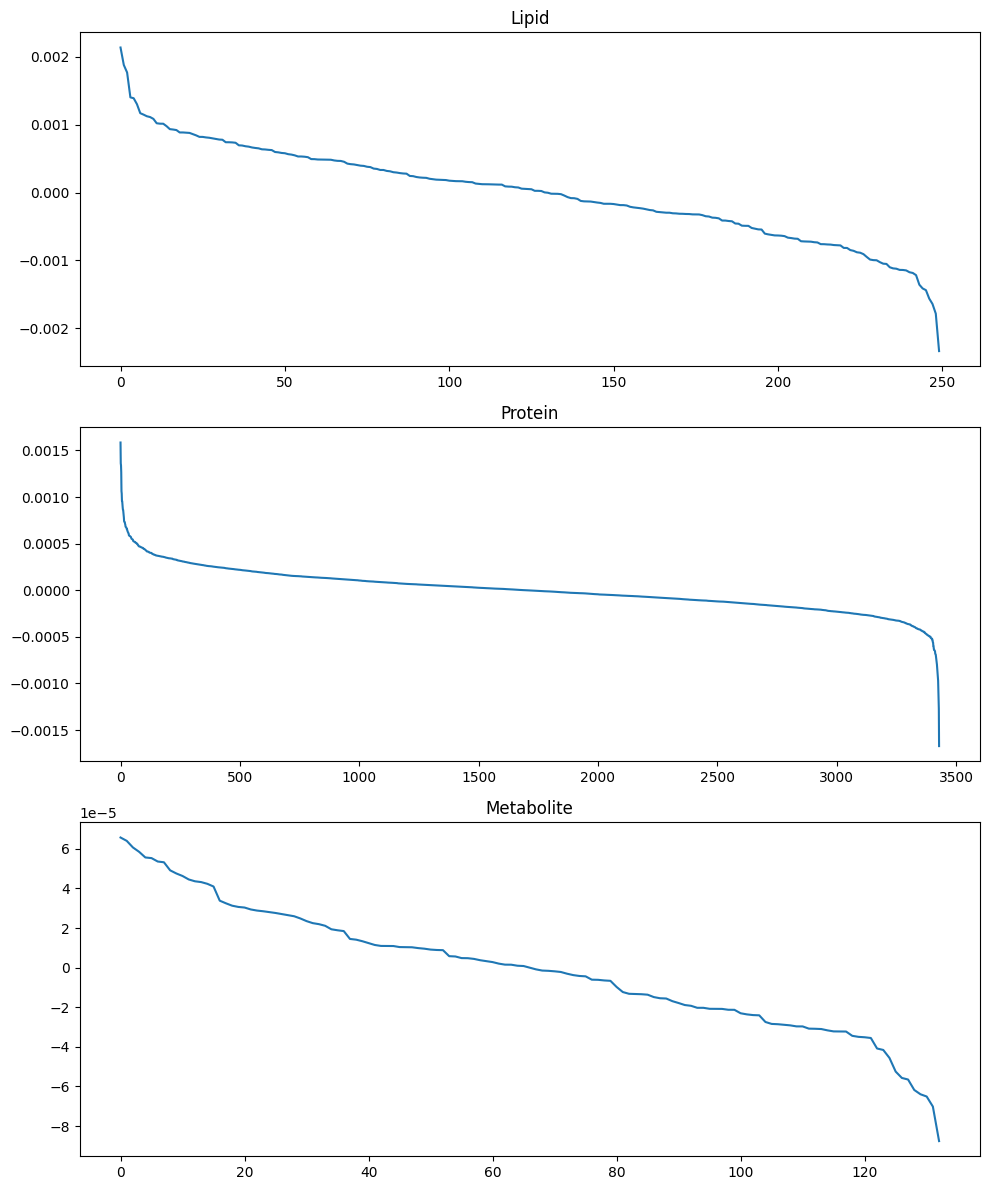

In [262]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize = (10, 12))
axs[0].plot(sorted(lip_int_scores.sum(axis = 0).numpy(), reverse = True))
axs[1].plot(sorted(pro_int_scores.sum(axis = 0).numpy(), reverse = True))
axs[2].plot(sorted(metab_int_scores.sum(axis = 0).numpy(), reverse = True))

axs[0].set_title('Lipid')
axs[1].set_title('Protein')
axs[2].set_title('Metabolite')

plt.tight_layout()

In [263]:
lip_ranks = {}
pro_ranks = {}
metab_ranks = {}

for k in range(50):
    lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
    pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
    metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

    lip_int_scores, metab_int_scores, pro_int_scores = integrated_grads(
        [liptest_pos, metabtest_pos, protest_pos], 
        [lip_baseline, metab_baseline, pro_baseline], 
        joint_model, n_steps = 100, class_idx = 1
    )

    lip_argsort = lip_int_scores.sum(axis = 0).argsort()
    pro_argsort = pro_int_scores.sum(axis = 0).argsort()
    metab_argsort = metab_int_scores.sum(axis = 0).argsort()

    for r, i in enumerate(lip_argsort.numpy()):
        lip_ranks.setdefault(i, []).append(r)
    
    for r, i in enumerate(pro_argsort.numpy()):
        pro_ranks.setdefault(i, []).append(r)

    for r, i in enumerate(metab_argsort.numpy()):
        metab_ranks.setdefault(i, []).append(r)

In [264]:
lip_mu_std = {k: (np.mean(v), np.std(v)) for k, v in lip_ranks.items()}
pro_mu_std = {k: (np.mean(v), np.std(v)) for k, v in pro_ranks.items()}
metab_mu_std = {k: (np.mean(v), np.std(v)) for k, v in metab_ranks.items()}

In [268]:
# sort lip_mu_std by the std
sorted(lip_mu_std.items(), key = lambda x: x[1][0], reverse = False)[:10]

[(3, (0.0, 0.0)),
 (236, (1.58, 1.0215674231297707)),
 (45, (3.98, 3.449579684541292)),
 (35, (4.7, 3.9912404086950213)),
 (152, (4.96, 3.3344264874187886)),
 (211, (6.88, 2.329291737846507)),
 (5, (7.6, 3.5888716889852725)),
 (2, (7.96, 4.911048767829535)),
 (201, (8.2, 2.5298221281347035)),
 (4, (9.8, 3.3226495451672298))]

In [266]:
sorted(pro_mu_std.items(), key = lambda x: x[1][1], reverse = False)[:10]

[(3207, (3428.94, 0.23748684174075835)),
 (2190, (0.32, 0.466476151587624)),
 (1189, (0.68, 0.466476151587624)),
 (1188, (2.66, 0.8151073548925932)),
 (3208, (3427.48, 0.9641576634555159)),
 (383, (3426.46, 1.2682271089990151)),
 (3210, (3425.52, 1.4455448799674122)),
 (3209, (3425.26, 1.5467385040788246)),
 (2962, (3.26, 1.5976232346833217)),
 (598, (3424.42, 1.7898603297464304))]

In [267]:
sorted(metab_mu_std.items(), key = lambda x: x[1][1], reverse = False)[:10]

[(51, (0.1, 0.4999999999999999)),
 (43, (65.68, 0.705407683541936)),
 (131, (55.96, 0.7472616676907761)),
 (93, (69.96, 0.7472616676907762)),
 (95, (67.34, 0.7644605941446557)),
 (120, (54.52, 0.7807688518377254)),
 (78, (71.84, 0.8089499366462674)),
 (72, (58.08, 0.9130169768410661)),
 (9, (68.58, 0.94)),
 (53, (62.3, 0.9848857801796104))]

# Train on TCGA

The TCGA dataset was processed as in (Lee and van der Schaar, 2021).  The features are kernel-PCA representations of the
TCGA gene expression data.  The labels are the 1 year mortality status of the patients.

In [2]:
# load pre-processed tcga data
tcgadata = np.load('/Users/clab683/Documents/Data/tcga/multi_omics_1yr_mortality.npz')

In [3]:
rnaseq = torch.tensor(tcgadata['mRNAseq']).float()
methyl = torch.tensor(tcgadata['Methylation']).float()
mirna = torch.tensor(tcgadata['miRNAseq']).float()
rppa = torch.tensor(tcgadata['RPPA']).float()
labels = torch.tensor(tcgadata['label']).reshape(-1).long()

# sample train indices
train_inds = np.random.choice(len(rnaseq), size=int(len(rnaseq) * 0.7), replace=False)
valid_inds = np.setdiff1d(np.arange(len(rnaseq)), train_inds)
test_inds = np.random.choice(valid_inds, size=int(len(valid_inds) * 0.5), replace=False)
valid_inds = np.setdiff1d(valid_inds, test_inds)

# create train, valid, and test tensors
rnaseq_train = rnaseq[train_inds]
methyl_train = methyl[train_inds]
mirna_train = mirna[train_inds]
rppa_train = rppa[train_inds]
labels_train = labels[train_inds]

rnaseq_valid = rnaseq[valid_inds]
methyl_valid = methyl[valid_inds]
mirna_valid = mirna[valid_inds]
rppa_valid = rppa[valid_inds]
labels_valid = labels[valid_inds]

rnaseq_test = rnaseq[test_inds]
methyl_test = methyl[test_inds]
mirna_test = mirna[test_inds]
rppa_test = rppa[test_inds]
labels_test = labels[test_inds]

# dataloaders
train_dataset = torch.utils.data.TensorDataset(rnaseq_train, methyl_train, mirna_train, rppa_train, labels_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = torch.utils.data.TensorDataset(rnaseq_valid, methyl_valid, mirna_valid, rppa_valid, labels_valid)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(rnaseq_test, methyl_test, mirna_test, rppa_test, labels_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

### Build the model

In [183]:
# reload these modules with sys and importlib
import sys
import importlib

# import the modules
importlib.reload(sys.modules['models.fc_imv'])
from models.fc_imv import FC_Marginal, JointVAE

# three view-specific encoders with the appropriate input size:
marg_model = FC_Marginal(input_size=100, hidden_sizes=[256, 256], z_dim=32, prediction_dim=labels.unique().size()[0])

# joint model
joint_model = JointVAE(marginal_models=[copy.deepcopy(marg_model) for _ in range(4)], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

## Training

To facilitate training, we need to group samples into sub-batches with similar view-missing patterns.  In a single batch, there may be several sub-batches that we feed through the model one by one.  We accumulate the loss over these sub-batches and update the gradients one all sub-batches have been passed forward.

The classes are heavily imbalanced, about 80% of patients survive to 1 year.  I use a class-balanced focal loss to address this issue.

In [184]:
# a function to build batches that group together batches of samples with the same view-missing patterns
def build_combo_batches(views):
    num_view_missing = []

    for view in views:
        na_views = torch.isnan(view).sum(axis = 1) > 0
        num_view_missing.append(na_views)

    which_na = torch.stack(num_view_missing, axis = 1)

    input_dict = {}
    gt_dict = {}

    comb = torch.unique(which_na, dim = 0)[0]
    which_na == comb.unsqueeze(0)

    for comb in torch.unique(which_na, dim = 0):
        inds = (which_na == comb.unsqueeze(0)).all(axis = 1)
        input_batch = [views[i][inds] if not comb[i] else None for i in range(len(views))]

        gt_dict[comb] = y[inds]
        input_dict[comb] = input_batch

    return input_dict, gt_dict

In [ ]:
# handle class imbalance
alpha = torch.tensor([1/0.9391, 1/0.1609])
# focal constant 
gamma = 3

for epoch in range(40):
    accumulate_loss = []
    for idx, batch in enumerate(train_loader):
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = x_rnaseq, x_methyl, x_mirna, x_clinical

        input_dict, gt_dict = build_combo_batches(views)

        loss = 0
        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            yhat, poe_dist, yhats, dists = joint_model(x)
            # pass alpha and gamma to do focal loss
            tmp_loss = joint_model.loss(y_gt, yhat, poe_dist, yhats, dists, alpha = alpha, gamma = gamma)
            loss += tmp_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
        optimizer.step()

        if idx % 50 == 0 and idx != 0:
            print(loss.item())

        accumulate_loss.append(loss.item())

    joint_model.eval()
    allpreds = []
    all_gt = []
    
    for batch in valid_loader:
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

        num_view_missing = []

        input_dict, gt_dict = build_combo_batches(views)

        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            with torch.inference_mode():
                yhat, poe_dist, yhats, dists = joint_model(x)
            preds = yhat.argmax(axis = 1) == y_gt
            allpreds.extend(preds.tolist())
            all_gt.extend(y_gt.tolist())

    pred_1 = np.array(allpreds)[np.array(all_gt) == 1]
    pred_0 = np.array(allpreds)[np.array(all_gt) == 0]
        
    joint_model.train()
    print(f"Average loss for epoch {epoch} is {np.mean(accumulate_loss)}, validation accuracy: 0: {np.mean(pred_0)}, 1: {np.mean(pred_1)}")

## Evaluation on test set

In [192]:
joint_model.eval()
all_preds = []
all_gt = []
y_score = []

for batch in test_loader:
    x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
    views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

    num_view_missing = []

    input_dict, gt_dict = build_combo_batches(views)

    for comb, x in input_dict.items():
        y_gt = gt_dict[comb]
        with torch.inference_mode():
            yhat, poe_dist, yhats, dists = joint_model(x)
        preds = yhat.argmax(axis = 1)
        all_preds.extend(preds.tolist())
        all_gt.extend(y_gt.tolist())
        y_score.extend(yhat[:, 1].tolist())

In [193]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_gt, y_score)
auc(fpr, tpr)

0.8043450479233225

In [196]:
confusion_matrix(all_gt, all_preds)

array([[917,  22],
       [133,  17]])

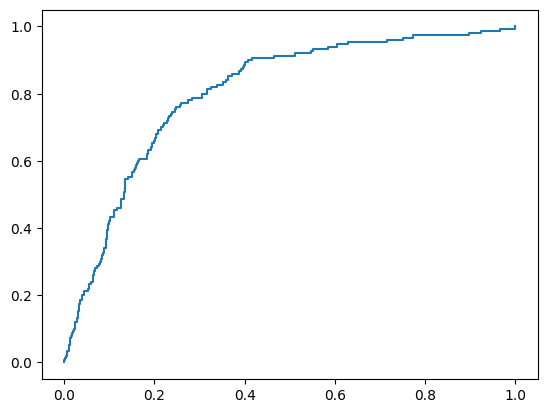

In [189]:
plt.plot(fpr, tpr)

In [ ]:
# drop protein rows with all NA values 

# get indices with all nan values
# train_inds = (train_pro.isnull() == False).sum(axis = 1) > 0
# test_inds = (test_pro.isnull() == False).sum(axis = 1) > 0

# bad_inds = train_inds * test_inds

# # drop bad_inds
# train_pro = train_pro[bad_inds]
# test_pro = test_pro[bad_inds]

# # same for lipids and metabolites:
# train_inds = (train_lip.isnull() == False).sum(axis = 1) > 0
# test_inds = (test_lip.isnull() == False).sum(axis = 1) > 0

# bad_inds = train_inds * test_inds

# train_lip = train_lip[bad_inds]
# test_lip = test_lip[bad_inds]

# train_inds = (train_metab.isnull() == False).sum(axis = 1) > 0
# test_inds = (test_metab.isnull() == False).sum(axis = 1) > 0

# bad_inds = train_inds * test_inds

# train_metab = train_metab[bad_inds]
# test_metab = test_metab[bad_inds]
